<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Aprendizaje Automático Avanzado</h1>
    <h3>Gaussian Mixture Models y modelos de mezcla bayesianos</h3>
</div>

Los modelos de mezcla gaussiana son **modelos probabilísticos**, utilizan un enfoque de **clustering suave**, en el que cada punto puede pertenecer parcialmente a varios clusters. Un GMM supone que los datos fueron generados por cierto número de distribuciones gaussianas y que cada distribución representa un cluster. Por ello, tiende a agrupar juntos los puntos que pertenecen a una misma distribución.


## Modelos de mezcla gaussiana (GMM)

Un **GMM** supone que cada observación $x_i\in\mathbb{R}^D$ fue generada por uno de $K$ componentes gaussianos. La variable latente $z_i\in\{1,\ldots,K\}$ indica qué componente generó el punto, pero no la observamos.

### Modelo generativo

Cada componente tiene una media $\mu_k$, una matriz de covarianza $\Sigma_k$ y un peso $\pi_k$:

$$\pi_k\geq0,\qquad \sum_{k=1}^{K}\pi_k=1$$

La densidad de una gaussiana multivariada es:

$$\mathcal{N}(x\mid\mu_k,\Sigma_k)=\frac{1}{(2\pi)^{D/2}|\Sigma_k|^{1/2}}\exp\left[-\frac{1}{2}(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k)\right]$$

El modelo completo es una suma ponderada:

$$p(x)=\sum_{k=1}^{K}\pi_k\,\mathcal{N}(x\mid\mu_k,\Sigma_k)$$

- $\mu_k$ determina el centro del componente.
- $\Sigma_k$ determina su dispersión, orientación y forma.
- $\pi_k$ representa la proporción esperada de observaciones generadas por el componente.

Para una muestra de datos independientes, la verosimilitud es:

$$\mathcal{L}(\theta\mid X)=\prod_{i=1}^{n}p(x_i\mid\theta)$$

En la práctica se maximiza la [log-verosimilitud](https://es.wikipedia.org/wiki/M%C3%A1xima_verosimilitud), que es más estable numéricamente:

$$\log\mathcal{L}(\theta\mid X)=\sum_{i=1}^{n}\log\left(\sum_{k=1}^{K}\pi_k\mathcal{N}(x_i\mid\mu_k,\Sigma_k)\right)$$

### Clustering duro y suave

- **Clustering duro** (*hard*, p. ej. K-Means): cada punto pertenece a **un solo** cluster. Asigna $x_i$ al componente más probable, $\hat z_i=\arg\max_k r_{ik}$.

  
- **Clustering suave** (*soft*, probabilístico): cada punto tiene una **probabilidad** de pertenecer a **cada** cluster. conserva todas las probabilidades posteriores $r_{ik}=P(z_i=k\mid x_i)$.

```
   K-Means (duro)              GMM (suave)

   punto → Cluster A           punto → 70% A, 25% B, 5% C
```

> El clustering probabilístico asume que los datos fueron **generados** por una **mezcla de distribuciones** (normalmente gaussianas). El objetivo es **descubrir esas distribuciones**.

Por el teorema de Bayes, la responsabilidad del componente $k$ sobre el punto $x_i$ es:

$$r_{ik}=\frac{\pi_k\mathcal{N}(x_i\mid\mu_k,\Sigma_k)}{\sum_{j=1}^{K}\pi_j\mathcal{N}(x_i\mid\mu_j,\Sigma_j)}$$

Para cada observación, las responsabilidades forman una distribución:

$$0\leq r_{ik}\leq1,\qquad\sum_{k=1}^{K}r_{ik}=1$$

> Un punto situado entre dos componentes puede tener, por ejemplo, $r_{i1}=0.55$ y $r_{i2}=0.45$. Obligar una etiqueta única ocultaría esa incertidumbre.

### El algoritmo EM (Expectation-Maximization)

EM alterna dos pasos hasta que la log-verosimilitud deja de mejorar significativamente:

1. **Inicialización:** elegir $\pi_k$, $\mu_k$ y $\Sigma_k$ iniciales, por ejemplo a partir de K-Means.
2. **Paso E:** calcular $r_{ik}$ con la ecuación de Bayes anterior.
3. **Paso M:** calcular el número efectivo de puntos del componente:

   $$N_k=\sum_{i=1}^{n}r_{ik}$$

   y actualizar:

   $$\mu_k=\frac{1}{N_k}\sum_{i=1}^{n}r_{ik}x_i$$

   $$\Sigma_k=\frac{1}{N_k}\sum_{i=1}^{n}r_{ik}(x_i-\mu_k)(x_i-\mu_k)^T$$

   $$\pi_k=\frac{N_k}{n}$$

4. **Convergencia:** detenerse cuando el incremento de la log-verosimilitud sea menor que `tol` o se alcance `max_iter`.

EM mejora la verosimilitud en cada iteración, pero solo garantiza converger a un óptimo local. Por eso conviene usar varias inicializaciones (`n_init`) y comparar la solución final.

#### **Limitaciones de K-Means (Clustering duro)**

Por ejemplo, si tenemos grupos de datos compactos, K-Means puede etiquetarlos rápidamente de una forma muy parecida a la que identificaríamos visualmente:

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns; sns.set()
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Generar algunos datos
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=400, centers=4,
                       cluster_std=0.60, random_state=0)
X = X[:, ::-1] # invertir ejes para mejorar la visualización

# Graficar los datos con etiquetas de K-Means
kmeans = KMeans(4, random_state = 0)
labels = kmeans.fit_predict(X)
labels


array([0, 2, 2, 1, 2, 0, 3, 1, 2, 3, 0, 3, 1, 2, 2, 3, 2, 3, 1, 2, 2, 2,
       0, 1, 1, 0, 0, 1, 1, 3, 1, 1, 2, 1, 2, 0, 3, 1, 3, 1, 2, 0, 3, 1,
       3, 0, 3, 3, 3, 0, 0, 0, 2, 0, 0, 2, 1, 3, 3, 2, 3, 3, 3, 3, 1, 2,
       3, 1, 2, 0, 2, 1, 2, 0, 3, 2, 1, 2, 0, 2, 2, 1, 3, 0, 1, 2, 2, 1,
       2, 3, 2, 3, 1, 2, 2, 0, 1, 3, 3, 3, 0, 3, 1, 1, 2, 0, 1, 0, 3, 2,
       2, 2, 1, 2, 0, 3, 0, 2, 0, 0, 3, 2, 3, 0, 1, 0, 3, 3, 3, 1, 0, 0,
       0, 2, 1, 2, 0, 1, 0, 2, 1, 2, 2, 0, 2, 3, 1, 2, 3, 2, 3, 1, 3, 1,
       0, 2, 3, 2, 2, 2, 1, 2, 0, 2, 2, 0, 3, 3, 2, 0, 0, 0, 0, 3, 3, 3,
       1, 2, 1, 0, 1, 0, 2, 1, 0, 2, 0, 1, 1, 0, 1, 1, 0, 2, 0, 0, 0, 3,
       3, 1, 1, 2, 3, 3, 0, 1, 2, 0, 1, 0, 1, 1, 3, 3, 0, 3, 1, 0, 3, 0,
       2, 1, 0, 2, 2, 2, 3, 0, 1, 0, 1, 2, 1, 1, 0, 3, 2, 3, 1, 2, 3, 1,
       1, 0, 3, 1, 0, 1, 3, 2, 2, 3, 2, 1, 0, 0, 1, 1, 3, 0, 1, 2, 2, 2,
       0, 1, 1, 1, 1, 1, 3, 1, 1, 0, 2, 3, 0, 3, 3, 3, 0, 3, 3, 0, 0, 0,
       3, 1, 3, 1, 3, 2, 1, 3, 2, 1, 3, 3, 1, 2, 0,

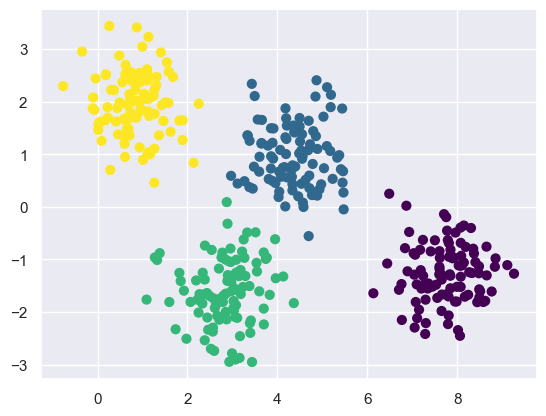

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis')


- Desde una perspectiva intuitiva, esperamos que la asignación de algunos puntos sea más segura que la de otros.
- Por ejemplo, parece existir un ligero solapamiento entre los dos clusters centrales, por lo que no podemos estar completamente seguros de la asignación de los puntos situados entre ellos.

- **Desafortunadamente, K-Means no incorpora una medida de probabilidad o incertidumbre para sus asignaciones** (aunque podríamos estimarla mediante bootstrap).
- Para resolver esta limitación, necesitamos generalizar el modelo.

- K-Means puede interpretarse como un círculo, o una hiperesfera en dimensiones superiores, colocado en el centro de cada cluster y con un radio determinado por el punto más alejado.
- Ese radio actúa como un límite rígido: cualquier punto situado fuera del círculo no se considera miembro del cluster.

Podemos visualizar este modelo de clusters con la siguiente función:

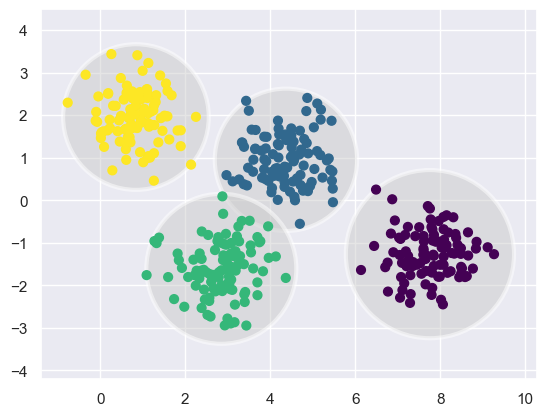

In [5]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

def plot_kmeans(kmeans, X, n_clusters=4, rseed=0, ax=None):
    labels = kmeans.fit_predict(X)

    # plot the input data
    ax = ax or plt.gca()
    ax.axis('equal')
    ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2)

    # plot the representation of the KMeans model
    centers = kmeans.cluster_centers_
    radii = [cdist(X[labels == i], [center]).max()
             for i, center in enumerate(centers)]
    for c, r in zip(centers, radii):
        ax.add_patch(plt.Circle(c, r, fc='#CCCCCC', lw=3, alpha=0.5, zorder=1))
  
kmeans = KMeans(n_clusters=4, random_state=0)
plot_kmeans(kmeans, X)

- Una observación importante es que los modelos de clusters de K-Means **deben ser circulares**: K-Means no tiene una forma integrada de representar clusters alargados o elípticos.
- Por ejemplo, si tomamos los mismos datos y los transformamos, las asignaciones se vuelven confusas:

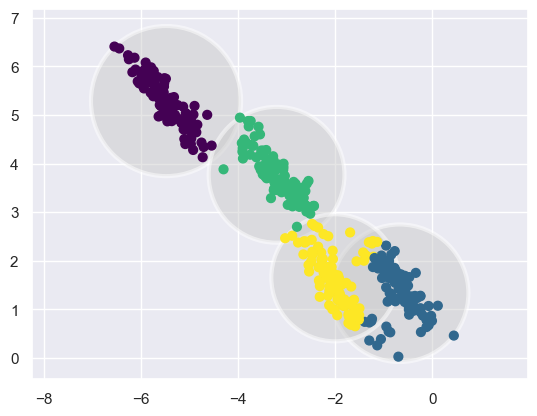

In [6]:
rng = np.random.RandomState(13)
X_stretched = np.dot(X, rng.randn(2, 2))

kmeans = KMeans(n_clusters=4, random_state=0)
plot_kmeans(kmeans, X_stretched)

- Visualmente reconocemos que estos clusters transformados no son circulares, por lo que los círculos serían un ajuste deficiente. Sin embargo, K-Means no es suficientemente flexible y fuerza los datos a formar cuatro clusters circulares.
- Esto mezcla las asignaciones y produce círculos solapados, especialmente en la parte inferior derecha de la figura.
- Podríamos intentar resolver esta situación preprocesando los datos con PCA, pero no hay garantía de que una transformación global vuelva circulares todos los clusters individuales.

- **Estas son dos desventajas principales de K-Means:**
  1. Poca flexibilidad en la forma de los clusters.
  2. Ausencia de una asignación probabilística, lo que puede perjudicar el desempeño en muchos conjuntos de datos, especialmente en dimensiones bajas.

**Posible solución**
1. Generalizar K-Means y medir la incertidumbre comparando la distancia de cada punto con todos los centros, en lugar de considerar solo el más cercano.
2. Permitir que las fronteras sean elipses en lugar de círculos para representar clusters no circulares.

Estos dos elementos son componentes esenciales de otro modelo de clustering: los **modelos de mezcla gaussiana**.

### Ejemplo con scikit-learn

`GaussianMixture` y `BayesianGaussianMixture` vienen incluidos en scikit-learn, no requieren instalación adicional.

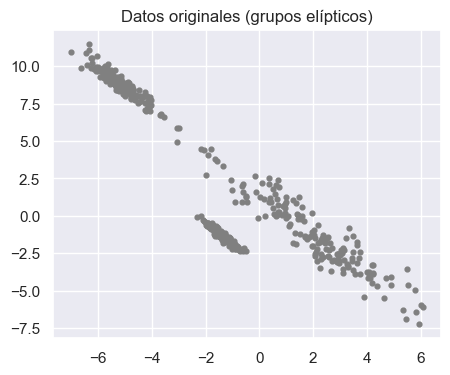

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Tres grupos con formas alargadas (covarianza no esférica)
X, _ = make_blobs(n_samples=500, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=42)
transform = np.array([[0.6, -0.6], [-0.4, 0.8]])
X = X @ transform   # deformar los grupos para que no sean circulares

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], s=12, color='gray')
plt.title('Datos originales (grupos elípticos)')
plt.show()

### Ejemplo base: datos simulados

Trabajaremos con tres grupos de forma elíptica. La transformación lineal modifica la geometría de los datos, de modo que la covarianza completa sea relevante.

Antes de ajustar el modelo conviene revisar la escala de las variables. **GMM** usa densidades gaussianas y, por tanto, una variable con unidades mucho mayores puede dominar las distancias y las covarianzas. En datos reales suele ser recomendable estandarizar o transformar las variables, siempre que esa operación tenga sentido en el dominio.

In [8]:
#Importando la libbrería
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)


# asignación dura (cluster más probable)
labels = gmm.predict(X)

# asignación suave (probabilidades)
proba = gmm.predict_proba(X)


In [9]:
proba

array([[9.99999975e-001, 4.16858062e-065, 2.49653813e-008],
       [5.66186362e-095, 1.86221872e-010, 1.00000000e+000],
       [0.00000000e+000, 1.26502428e-056, 1.00000000e+000],
       ...,
       [1.76071993e-296, 7.38526461e-011, 1.00000000e+000],
       [9.99999985e-001, 1.15049177e-060, 1.52243169e-008],
       [0.00000000e+000, 4.11859444e-019, 1.00000000e+000]])

In [10]:
labels

array([0, 2, 2, 1, 2, 2, 0, 2, 2, 0, 2, 1, 1, 1, 2, 2, 1, 0, 0, 1, 2, 1,
       2, 0, 0, 2, 2, 0, 0, 1, 2, 1, 1, 1, 2, 2, 2, 2, 0, 0, 2, 1, 1, 1,
       1, 2, 2, 2, 2, 0, 0, 1, 0, 0, 2, 1, 1, 0, 2, 0, 0, 1, 2, 0, 2, 0,
       2, 0, 1, 2, 2, 2, 2, 0, 1, 0, 1, 2, 1, 1, 0, 1, 2, 1, 0, 0, 0, 0,
       2, 1, 0, 2, 1, 2, 2, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 2, 1, 0, 2, 0, 1, 1, 2, 2, 0, 2, 1, 2, 0, 0, 0, 2,
       2, 0, 2, 0, 0, 0, 2, 1, 0, 0, 2, 2, 0, 0, 0, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 1, 0, 2, 2, 0, 0, 1, 1, 0, 1, 1, 2, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 2, 2, 2, 1, 0, 1, 1, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 1, 2, 1, 1,
       0, 2, 1, 1, 0, 0, 2, 0, 2, 1, 1, 0, 0, 2, 0, 1, 1, 0, 1, 0, 1, 2,
       2, 1, 0, 1, 2, 1, 1, 0, 2, 2, 2, 2, 1, 0, 0, 0, 1, 2, 1, 2, 2, 2,
       1, 1, 0, 0, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       2, 2, 2, 1, 2, 2, 1, 1, 2, 0, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1, 0, 1,
       2, 0, 2, 2, 0, 1, 1, 1, 0, 1, 0, 2, 2, 1, 2,

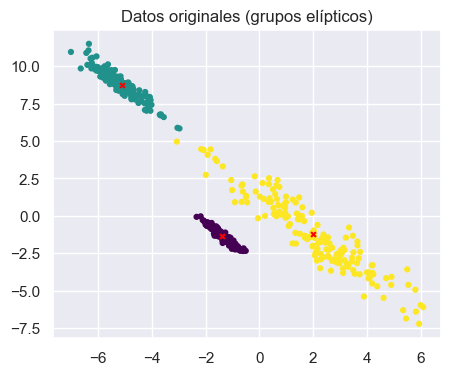

In [13]:
plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], s=12, c=labels, cmap='viridis')
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], s=12, color='red', marker='x')

plt.title('Datos originales (grupos elípticos)')
plt.show()

In [11]:
from sklearn.metrics import silhouette_score

predicciones = gmm.predict(X)
responsabilidades = gmm.predict_proba(X)
print(f'Log-verosimilitud media: {gmm.score(X):.3f}')
print(f'Convergencia: {gmm.converged_} en {gmm.n_iter_} iteraciones')
print(f'Silueta de las etiquetas duras: {silhouette_score(X, predicciones):.3f}')

# Las filas de la matriz de responsabilidades siempre deben sumar 1.
print('Suma de responsabilidades, primeras 3 observaciones:', responsabilidades[:3].sum(axis=1).round(3))

Log-verosimilitud media: -2.606
Convergencia: True en 8 iteraciones
Silueta de las etiquetas duras: 0.615
Suma de responsabilidades, primeras 3 observaciones: [1. 1. 1.]


### Interpretar el ajuste

`predict` produce la etiqueta del componente con mayor responsabilidad. `predict_proba` conserva la matriz $R=[r_{ik}]$, que es más informativa cuando hay solapamiento.

La media global del modelo y su covarianza se pueden expresar como:

$$\mathbb{E}[x]=\sum_{k=1}^{K}\pi_k\mu_k$$

$$\operatorname{Cov}(x)=\sum_{k=1}^{K}\pi_k\left[\Sigma_k+(\mu_k-\mathbb{E}[x])(\mu_k-\mathbb{E}[x])^T\right]$$

La primera parte de la covarianza representa la dispersión dentro de cada componente; la segunda representa la separación entre sus medias.

### Visualizar la incertidumbre (soft clustering)

El tamaño de cada punto refleja la **confianza** de su asignación: puntos en las fronteras entre clusters son más pequeños (más inciertos).

In [15]:
proba

array([[9.99999975e-001, 4.16858062e-065, 2.49653813e-008],
       [5.66186362e-095, 1.86221872e-010, 1.00000000e+000],
       [0.00000000e+000, 1.26502428e-056, 1.00000000e+000],
       ...,
       [1.76071993e-296, 7.38526461e-011, 1.00000000e+000],
       [9.99999985e-001, 1.15049177e-060, 1.52243169e-008],
       [0.00000000e+000, 4.11859444e-019, 1.00000000e+000]])

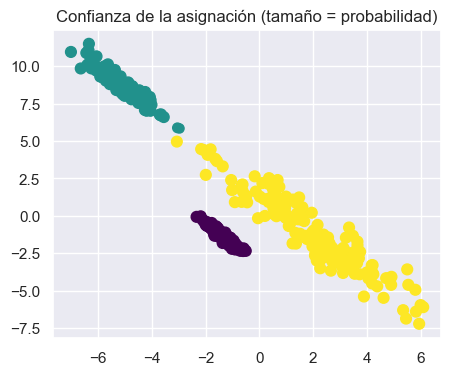

In [14]:
confianza = proba.max(axis=1)   # probabilidad del cluster asignado

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=confianza * 60)
plt.title('Confianza de la asignación (tamaño = probabilidad)')
plt.show()

### Ejemplo: incertidumbre punto a punto

La etiqueta de `predict` es una decisión resumida, mientras que `predict_proba` permite conservar la información completa. Podemos identificar observaciones ambiguas mediante la entropía de sus responsabilidades:

$$H(r_i)=-\sum_{k=1}^{K}r_{ik}\log r_{ik}$$

Una entropía cercana a cero indica una asignación segura; una entropía alta indica que varias componentes explican el punto de forma parecida.

Índices con mayor incertidumbre: [448  21 115 444 102 351 433 443  12 332]
Entropías correspondientes: [0.026 0.028 0.028 0.047 0.049 0.054 0.064 0.079 0.517 0.586]


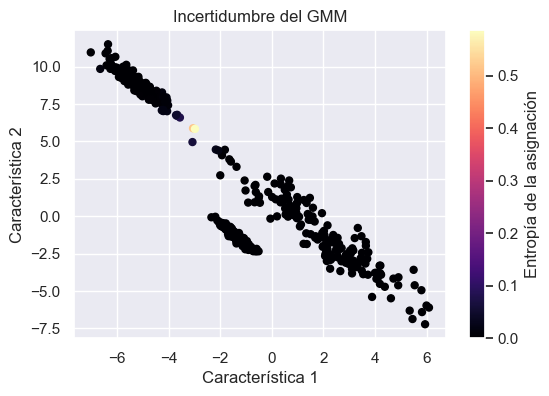

In [16]:
responsabilidades = np.clip(proba, 1e-12, 1.0)
entropia = -(responsabilidades * np.log(responsabilidades)).sum(axis=1)
indices_ambiguos = np.argsort(entropia)[-10:]

print('Índices con mayor incertidumbre:', indices_ambiguos)
print('Entropías correspondientes:', np.round(entropia[indices_ambiguos], 3))

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=entropia, cmap='magma', s=25)
plt.colorbar(label='Entropía de la asignación')
plt.title('Incertidumbre del GMM')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

## Ejemplo donde GMM no es suficiente

GMM representa cada componente con una región elíptica. Por eso funciona bien para grupos aproximadamente gaussianos, pero no necesariamente para estructuras curvas como dos medias lunas. En ese caso, aumentar el número de componentes puede mejorar la **estimación de densidad**, aunque las componentes ya no equivalen a los clusters semánticos originales.

In [ ]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=400, noise=0.06, random_state=42)

plt.figure(figsize=(6,4))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', s=14)
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', s=14)
axes[0].set_title('Medias lunas: referencia')
for ax, (nombre, modelo) in zip(axes[1:], modelos_moons.items()):
    etiquetas = modelo.fit_predict(X_moons)
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=etiquetas, cmap='viridis', s=14)
    ax.set_title(nombre)
for ax in axes:
    ax.set_xlabel('Característica 1')
    ax.set_ylabel('Característica 2')
plt.tight_layout()
plt.show()

## ¿Cuántos componentes elegir? Criterios AIC y BIC

A diferencia de DBSCAN, GMM requiere elegir el número de componentes $K$. Un valor demasiado pequeño no representa la distribución; uno demasiado grande puede sobreajustar el ruido.

Para comparar modelos usamos la log-verosimilitud penalizada. Si $\hat\theta_K$ es el ajuste con $K$ componentes y $k_K$ el número de parámetros libres:

$$AIC=-2\log\mathcal{L}(\hat\theta_K\mid X)+2k_K$$

$$BIC=-2\log\mathcal{L}(\hat\theta_K\mid X)+k_K\log n$$

- **AIC** penaliza la complejidad con $2k_K$ y suele tolerar modelos más grandes.
- **BIC** penaliza con $k_K\log n$ y normalmente favorece modelos más simples cuando $n>e^2$.
- En ambos casos, **menor es mejor**.

El número de parámetros depende de la dimensión $D$, el número de componentes y `covariance_type`. Por ejemplo, con covarianza completa, cada componente tiene $D$ medias y $D(D+1)/2$ elementos independientes de covarianza, además de sus pesos.

> AIC y BIC evalúan principalmente qué tan bien el GMM modela la densidad. No garantizan que las etiquetas sean la mejor solución de clustering para el objetivo del análisis.

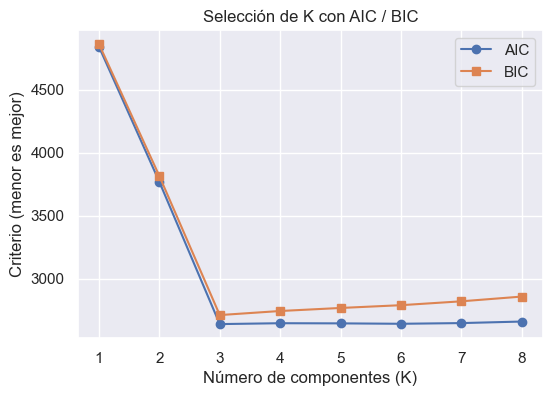

In [17]:
ks = range(1, 9)
aics, bics = [], []
for k in ks:
    g = GaussianMixture(n_components=k, covariance_type='full', random_state=42).fit(X)
    aics.append(g.aic(X))
    bics.append(g.bic(X))

plt.figure(figsize=(6, 4))
plt.plot(ks, aics, 'o-', label='AIC')
plt.plot(ks, bics, 's-', label='BIC')
plt.xlabel('Número de componentes (K)')
plt.ylabel('Criterio (menor es mejor)')
plt.title('Selección de K con AIC / BIC')
plt.legend()
plt.show()

## Modelos de mezcla bayesianos

El **Bayesian Gaussian Mixture** (mezcla gaussiana bayesiana) trata los parámetros del modelo como variables aleatorias. En lugar de buscar un único valor puntual para $\pi_k$, $\mu_k$ y $\Sigma_k$, combina los datos con distribuciones *a priori* y obtiene distribuciones posteriores.

Para los pesos de mezcla suele utilizarse un prior de Dirichlet:

$$p(\pi\mid\alpha)=\operatorname{Dirichlet}(\pi\mid\alpha_1,\ldots,\alpha_K)$$

con:

$$\pi_k\geq0,\qquad \sum_{k=1}^{K}\pi_k=1$$

La inferencia busca aproximar:

$$p(\pi,\mu,\Sigma,Z\mid X)\propto p(X\mid Z,\mu,\Sigma)\,p(Z\mid\pi)\,p(\pi)\,p(\mu,\Sigma)$$

Scikit-Learn utiliza inferencia variacional para aproximar esta distribución posterior. La idea es ajustar una distribución más sencilla $q(\Theta)$ que minimice la divergencia KL frente a la posterior verdadera:

$$q^*(\Theta)=\arg\min_q\operatorname{KL}\left(q(\Theta)\,\|\,p(\Theta\mid X)\right)$$

Ventaja clave:

> **No necesitas fijar el número exacto de componentes.** Proporcionas un límite superior `n_components` y el modelo puede reducir los pesos de los componentes innecesarios hacia cero.

`weight_concentration_prior` controla cuánto se favorecen mezclas dispersas. Un prior pequeño tiende a apagar más componentes; uno grande permite que más componentes conserven peso. Esta regularización bayesiana puede reducir el sobreajuste, pero el resultado sigue dependiendo del prior, de la inicialización y de la cantidad de datos.

In [18]:
from sklearn.mixture import BayesianGaussianMixture

# Damos un máximo de 10 componentes; el modelo usará solo los necesarios
pesos = np.array([0.5, 0.3, 0.2] + [0.0] * 7)  # pesos de mezcla conocidos
bgmm = BayesianGaussianMixture(n_components=10, weight_concentration_prior_type='dirichlet_process', weight_concentration_prior=1e-2, covariance_type='full', random_state=42)
bgmm.fit(X)

,n_components,10
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weight_concentration_prior_type,'dirichlet_process'
,weight_concentration_prior,0.01
,mean_precision_prior,None
,mean_prior,None


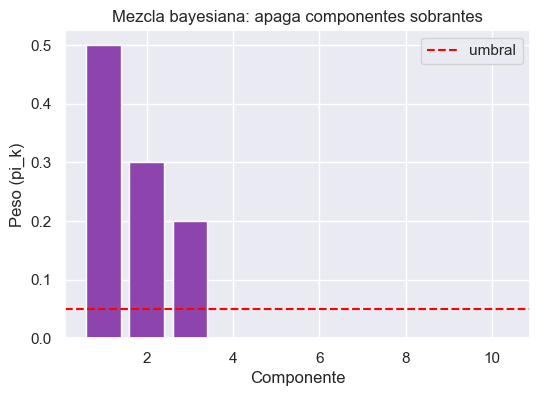

In [19]:
plt.figure(figsize=(6, 4))
plt.bar(range(1, 11), pesos, color='#8e44ad')
plt.axhline(0.05, color='red', ls='--', label='umbral')
plt.xlabel('Componente')
plt.ylabel('Peso (pi_k)')
plt.title('Mezcla bayesiana: apaga componentes sobrantes')
plt.legend()
plt.show()

### Interpretar los componentes activos

Un componente con peso posterior cercano a cero no está explicando una región relevante de los datos. Por eso contamos como activos los componentes cuyo peso supera un umbral, por ejemplo $\pi_k>0.05$.

Este umbral es una regla de visualización, no una prueba estadística. También conviene inspeccionar las medias, covarianzas, probabilidades de pertenencia y la sensibilidad al prior. Un modelo bayesiano no elimina la necesidad de diagnóstico: incorpora regularización e incertidumbre, pero sus conclusiones dependen del modelo elegido.

|  | **GMM** | **GMM bayesiano** |
|---|---|---|
| Número de componentes | Fijo; se puede elegir con AIC/BIC | Se proporciona un máximo y se regulariza automáticamente |
| Ajuste | EM y máxima verosimilitud | Inferencia variacional bayesiana |
| Forma de los componentes | Elíptica según la covarianza | Elíptica según la covarianza posterior |
| Sobreajuste | Riesgo si $K$ es grande | Se reduce mediante priors, pero no desaparece |
| Salida | Etiquetas, probabilidades y parámetros | Etiquetas, probabilidades y pesos regularizados |


### Flujo de trabajo recomendado

1. Estandarizar las variables y revisar valores atípicos.
2. Ajustar varios valores de $K$, tipos de covarianza e inicializaciones.
3. Comparar AIC/BIC, log-verosimilitud, silueta y visualizaciones.
4. Examinar probabilidades de pertenencia y observaciones ambiguas.
5. Validar que los clusters tengan sentido en el dominio de aplicación.

#### En Resumen

- El clustering probabilístico modela los datos como una mezcla de distribuciones, normalmente gaussianas.
- GMM define pesos $\pi_k$, medias $\mu_k$ y covarianzas $\Sigma_k$, y calcula la densidad mediante una suma ponderada.
- EM alterna el cálculo de responsabilidades y la actualización de parámetros; mejora la verosimilitud, pero puede converger a un óptimo local.
- `predict` produce una asignación dura y `predict_proba` conserva la incertidumbre de cada punto.
- La matriz de covarianza controla la forma, orientación y dispersión de cada componente.
- AIC y BIC ayudan a seleccionar $K$, aunque evalúan principalmente la calidad del modelo de densidad.
- El GMM bayesiano utiliza priors e inferencia variacional para reducir el peso de componentes innecesarios.
- GMM es apropiado cuando los grupos son aproximadamente gaussianos; para formas curvas o ruido severo conviene compararlo con métodos como DBSCAN, HDBSCAN o modelos más flexibles.

> La decisión final no debe basarse en una sola métrica: combina supuestos estadísticos, diagnóstico gráfico, incertidumbre y conocimiento del problema.